# Project: How do changes in interest rate and inflation affect overall household saving and borrowing behavior in japan after tom yum goong crisis using VAR/VECM?

## Introduction

### I. Background and Significance
- Why Japan?
- After this crisis, Japan entered a prolonged period of economic stagnation often referred to as the “Lost Decades.” During this time, the Bank of Japan implemented unconventional monetary policies, including near-zero and even negative interest rates, to stimulate economic activity. At the same time, Japan experienced persistent low inflation and periods of deflation, which contrasts with the typical inflationary environments observed in many other economies.
These conditions make Japan fundamentally different from standard macroeconomic settings where higher interest rates encourage saving and higher inflation discourages it. In Japan, the effectiveness of these traditional mechanisms is unclear and may be weakened or even reversed.

### II. Methodology
- The factor and model are inspire by this paper: A Brief Note on Thailand Household Debt Dynamics, Fisher Effects, and Monetary Policy Transmission (Teerapap Pangsapa, Thanaphol Kongphalee, and Maneerat Gongsiang, March 6, 2025).
- Use VAR model to see impulse response function for interpretation.

### III. Data
- Data has no NULL or Duplicates.
- Data is between 1997Q4 to 2025Q3 (28 years) from CEIC, FRED and IMF.
- Some data is seasonal adjusted by classical decomposition method.
- Only Real GDP YOY has seasonal adjustment by X13ARIMA because it from CEIC.
- Factor:
    1. Real GDP
    2. Fisher equation (Interest rate - CPI)
    3. Debt ratio (debt to nominal GDP)
    4. Saving ratio (saving to nominal GDP)
    5. Dubai Crude oil (Exogenous)

## 0. Set basics library & datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

In [2]:
RealGDP = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\RealGDP.xlsx")
RealGDPYOYsa = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\RealGDPYoYsa.xlsx")
IR = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\Interest Rate.xlsx")
CPI = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\CPI.xlsx")
DebtRatio = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\DebtRatio.xlsx")
SavingRatio = pd.read_excel(r"C:\Users\User\Desktop\Investment VAR\SavingRatio.xlsx")
Oil = pd.read_csv(r"C:\Users\User\Desktop\Investment VAR\Oil_formatted.csv")

In [3]:
for df in [RealGDP, RealGDPYOYsa, IR, CPI, DebtRatio, SavingRatio, Oil]:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')

start = '1997-10-01'
end = '2025-10-01'

RealGDP_sub = RealGDP[(RealGDP['Date'] >= start) & (RealGDP['Date'] <= end)].reset_index(drop=True)
RealGDPYOYsa_sub = RealGDPYOYsa[(RealGDPYOYsa['Date'] >= start) & (RealGDPYOYsa['Date'] <= end)].reset_index(drop=True)
IR_sub = IR[(IR['Date'] >= start) & (IR['Date'] <= end)].reset_index(drop=True)
CPI_sub = CPI[(CPI['Date'] >= start) & (CPI['Date'] <= end)].reset_index(drop=True)
DebtRatio_sub = DebtRatio[(DebtRatio['Date'] >= start) & (DebtRatio['Date'] <= end)].reset_index(drop=True)
SavingRatio_sub = SavingRatio[(SavingRatio['Date'] >= start) & (SavingRatio['Date'] <= end)].reset_index(drop=True)
Oil_sub = Oil[(Oil['Date'] >= start) & (Oil['Date'] <= end)].reset_index(drop=True)

real_ir = IR_sub.set_index('Date')['Interest Rate'].asfreq('QS-DEC') - CPI_sub.set_index('Date')['CPI'].asfreq('QS-DEC')

## 1. EDA

### 1.1 Plot graph
- Plot line graph to see is there a trend or seasonal to decide the next steps.
- Real GDP has trend, ADF-test using trend.
- Saving ratio has seasonal, seasonal adjust using additive method because amplitude is seem constant.
- Debt ratio, real_ir, oil has little seasonal, still need to seasonal adjust using additive method.
- Debt ratio, oil has structural break but we keep this the same because our knowledge isn't enough to fix.

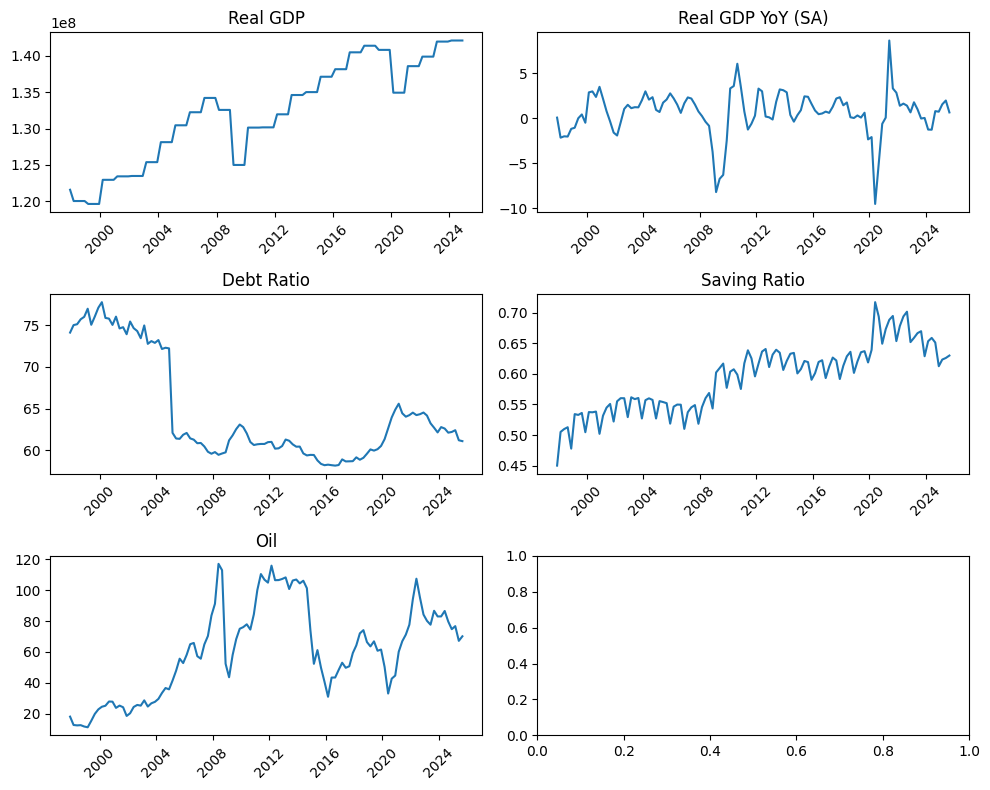

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

datasets = [
    (RealGDP_sub, 'Real GDP', 'RealGDP'),
    (RealGDPYOYsa_sub, 'Real GDP YoY (SA)', 'RealGDP:YOY:sa'),
    (DebtRatio_sub, 'Debt Ratio', 'Household Debt Ratio'),
    (SavingRatio_sub, 'Saving Ratio', 'SavingRatio'),
    (Oil_sub, 'Oil', 'DubaiCrude')
]

for ax, (df, title, col) in zip(axes.flatten(), datasets):
    ax.plot(df['Date'], df[col])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

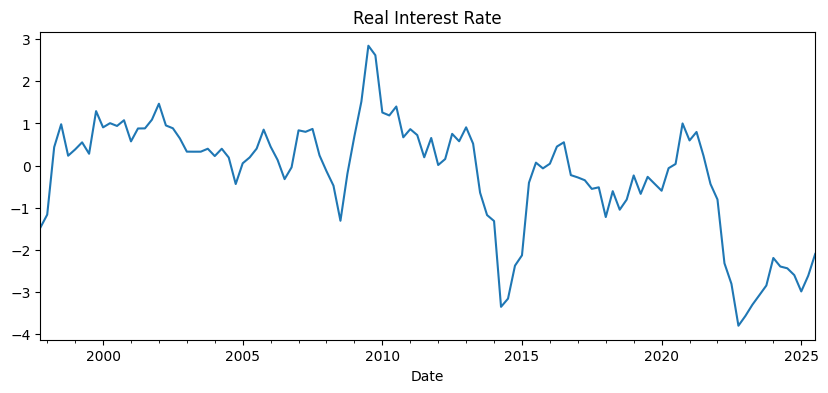

In [5]:
real_ir.plot(title='Real Interest Rate', figsize=(10, 4))
plt.show()

### 1.2 ADF-test
- We seasonal adjustment before ADF-test, result in only RealGDPYOYsa is stationary.

In [6]:
# Check date to adjust format
print(CPI_sub['Date'].head(8))

0   1997-12-01
1   1998-03-01
2   1998-06-01
3   1998-09-01
4   1998-12-01
5   1999-03-01
6   1999-06-01
7   1999-09-01
Name: Date, dtype: datetime64[us]


In [7]:
# ---- Step 1: Seasonal Adjustment ----
def seasonal_adjust(df, col):
    series = df.set_index('Date')[col]
    series = series.asfreq('QS-DEC')
    stl = STL(series, period=4)
    result = stl.fit()
    return series - result.seasonal

def seasonal_adjust_series(series):
    series = series.asfreq('QS-DEC')
    stl = STL(series, period=4)
    result = stl.fit()
    return series - result.seasonal

real_ir_sa = seasonal_adjust_series(real_ir)
DebtRatio_sa = seasonal_adjust(DebtRatio_sub, 'Household Debt Ratio')
SavingRatio_sa = seasonal_adjust(SavingRatio_sub, 'SavingRatio')
Oil_sa = seasonal_adjust(Oil_sub, 'DubaiCrude')

In [8]:
# Check
real_ir_sa

Date
1997-12-01   -1.055093
1998-03-01   -0.660699
1998-06-01    0.071864
1998-09-01    0.626769
1998-12-01    0.442608
                ...   
2024-09-01   -2.669867
2024-12-01   -2.403678
2025-03-01   -2.865881
2025-06-01   -2.639213
2025-09-01   -2.464720
Freq: QS-DEC, Length: 112, dtype: float64

In [9]:
# ---- Step 2: ADF Test ----
def adf_test(series, name, regression='c'):
    result = adfuller(series.dropna(), regression=regression)
    print(f"{name}")
    print(f"  ADF Stat: {result[0]:.4f}")
    print(f"  P-value:  {result[1]:.4f}")
    print(f"  Lags:     {result[2]}")
    print(f"  Result:   {'Stationary' if result[1] < 0.05 else 'Non-stationary'}")
    print()

# Real GDP, ADF-test add trend (regression='ct')
adf_test(RealGDP_sub.set_index('Date')['RealGDP'].asfreq('QS-DEC'), 'Real GDP', regression='ct')

# ADF-test add constant
adf_test(RealGDPYOYsa_sub.set_index('Date')['RealGDP:YOY:sa'].asfreq('QS-DEC'), 'Real GDP YoY (SA)')

# Has seasonal adjustment
adf_test(real_ir_sa, 'real_ir (SA)')
adf_test(DebtRatio_sa, 'Debt Ratio (SA)')
adf_test(SavingRatio_sa, 'Saving Ratio (SA)')
adf_test(Oil_sa, 'Oil (SA)')

Real GDP
  ADF Stat: -2.7727
  P-value:  0.2072
  Lags:     0
  Result:   Non-stationary

Real GDP YoY (SA)
  ADF Stat: -3.7253
  P-value:  0.0038
  Lags:     8
  Result:   Stationary

real_ir (SA)
  ADF Stat: -0.4831
  P-value:  0.8953
  Lags:     10
  Result:   Non-stationary

Debt Ratio (SA)
  ADF Stat: -2.4612
  P-value:  0.1252
  Lags:     13
  Result:   Non-stationary

Saving Ratio (SA)
  ADF Stat: -1.8987
  P-value:  0.3327
  Lags:     13
  Result:   Non-stationary

Oil (SA)
  ADF Stat: -1.9998
  P-value:  0.2866
  Lags:     9
  Result:   Non-stationary



### 1.3 First diff & another ADF-test
- We first diff, result in only real_ir_sa_diff & Oil_sa_diff is stationary
- After let function use auto selected lag, result in use 7 to 12 lags which is high than usual.
- Then we set maxlag to 4 (Thumb up for quarterly), result in all first diff are stationary.

In [10]:
# First difference
real_ir_sa_diff = real_ir_sa.diff().dropna()
DebtRatio_sa_diff = DebtRatio_sa.diff().dropna()
SavingRatio_sa_diff = SavingRatio_sa.diff().dropna()
Oil_sa_diff = Oil_sa.diff().dropna()


# ADF test on first differences
adf_test(real_ir_sa_diff, 'real_ir_sa (1st diff)')
adf_test(DebtRatio_sa_diff, 'Debt Ratio SA (1st diff)')
adf_test(SavingRatio_sa_diff, 'Saving Ratio SA (1st diff)')
adf_test(Oil_sa_diff, 'Oil SA (1st diff)')

real_ir_sa (1st diff)
  ADF Stat: -4.6368
  P-value:  0.0001
  Lags:     9
  Result:   Stationary

Debt Ratio SA (1st diff)
  ADF Stat: -2.2218
  P-value:  0.1984
  Lags:     12
  Result:   Non-stationary

Saving Ratio SA (1st diff)
  ADF Stat: -1.8611
  P-value:  0.3506
  Lags:     12
  Result:   Non-stationary

Oil SA (1st diff)
  ADF Stat: -3.7351
  P-value:  0.0036
  Lags:     11
  Result:   Stationary



In [11]:
def adf_test_maxlag(series, name, maxlag=8, regression='c'):
    result = adfuller(series.dropna(), maxlag=maxlag, regression=regression)
    print(f"{name}")
    print(f"  ADF Stat: {result[0]:.4f}")
    print(f"  P-value:  {result[1]:.4f}")
    print(f"  Lags:     {result[2]}")
    print(f"  Result:   {'Stationary' if result[1] < 0.05 else 'Non-stationary'}")
    print()

adf_test_maxlag(DebtRatio_sa_diff, 'Debt Ratio SA (1st diff, maxlag=8)')
adf_test_maxlag(SavingRatio_sa_diff, 'Saving Ratio SA (1st diff, maxlag=8)')

Debt Ratio SA (1st diff, maxlag=8)
  ADF Stat: -3.6597
  P-value:  0.0047
  Lags:     7
  Result:   Stationary

Saving Ratio SA (1st diff, maxlag=8)
  ADF Stat: -2.9007
  P-value:  0.0453
  Lags:     7
  Result:   Stationary



### 1.4 Joint data

In [12]:
var_df = pd.DataFrame({
    'RealGDPYOY_sa': RealGDPYOYsa_sub.set_index('Date')['RealGDP:YOY:sa'].asfreq('QS-DEC'),
    'RealIR_sa_d': real_ir_sa_diff,
    'DebtRatio_sa_d': DebtRatio_sa_diff,
    'SavingRatio_sa_d': SavingRatio_sa_diff,
    'Oil_sa_d': Oil_sa_diff
})

var_df = var_df.dropna()
print(var_df.head())
print(var_df.shape)

            RealGDPYOY_sa  RealIR_sa_d  DebtRatio_sa_d  SavingRatio_sa_d  \
Date                                                                       
1998-03-01      -2.133450     0.394394        0.465384          0.005110   
1998-06-01      -1.985236     0.732563        1.208694          0.009104   
1998-09-01      -2.009646     0.554905        0.106441          0.005231   
1998-12-01      -1.152140    -0.184161        0.226161          0.005091   
1999-03-01      -1.029817     0.285316        0.277530          0.012802   

            Oil_sa_d  
Date                  
1998-03-01 -1.506955  
1998-06-01 -0.810513  
1998-09-01 -1.113945  
1998-12-01 -2.047959  
1999-03-01  2.347704  
(111, 5)


## 2. VAR or VECM
- Factor:
    1. RealGDPYOYsa_sub
    2. real_ir_sa_diff
    3. DebtRatio_sa_diff
    4. SavingRatio_sa_diff
    5. Oil_sa_diff (Exogenous)

### 2.1 VAR model
- First, run VAR with BIC selection criteria with 4 lags
- Second, check autocorrelation test, due to BP-test is unavailable, we use "portmanteau test" instead, result in no autocorrelation.
- Third, check stability condition, found that all root are in circle which mean model are stability.
- Last, if pass the condition, then use granger cause to see which is significantly response.
- Next, we need to check cointegrate to decide what we will use VAR or VECM.

In [13]:
from statsmodels.tsa.api import VAR

endog_cols = ['RealGDPYOY_sa', 'RealIR_sa_d', 'DebtRatio_sa_d', 'SavingRatio_sa_d']
exog_cols = ['Oil_sa_d']

model = VAR(var_df[endog_cols], exog=var_df[exog_cols])

lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -9.539      -9.334   7.201e-05      -9.456
1      -10.69      -10.07   2.288e-05      -10.44
2      -10.67      -9.643   2.338e-05      -10.25
3      -10.79      -9.361   2.067e-05      -10.21
4      -12.11     -10.27*  5.586e-06*     -11.36*
5      -11.97      -9.721   6.491e-06      -11.06
6      -11.89      -9.230   7.167e-06      -10.81
7      -12.08      -9.006   6.107e-06      -10.83
8     -12.19*      -8.709   5.642e-06      -10.78
-------------------------------------------------


In [14]:
# Fit VAR(4)
results = model.fit(maxlags=4)

In [15]:
# 1. Portmanteau Test (multivariate)
pt = results.test_whiteness(nlags=16, adjusted=False)
print(f"Portmanteau Test:")
print(f"  Test Stat: {pt.test_statistic:.4f}")
print(f"  P-value:   {pt.pvalue:.4f}")
print(f"  Result:    {'No serial correlation' if pt.pvalue > 0.05 else 'Serial correlation detected'}")
print()

Portmanteau Test:
  Test Stat: 217.7614
  P-value:   0.0979
  Result:    No serial correlation



In [16]:
# 2. Stability Condition
print("Stability Condition:")
print(f"  All eigenvalues inside unit circle: {results.is_stable()}")
print(f"  Max eigenvalue: {max(abs(results.roots)):.4f}")

Stability Condition:
  All eigenvalues inside unit circle: True
  Max eigenvalue: 1.7849


In [17]:
# 3. Granger Causality Test
print("Granger Causality Test")
print("=" * 60)

for caused in endog_cols:
    for causing in endog_cols:
        if caused != causing:
            test = results.test_causality(caused, causing)
            sig = '***' if test.pvalue < 0.05 else ''
            print(f"  {causing} -> {caused}: F={test.test_statistic:.4f}, P={test.pvalue:.4f} {sig}")
    print()

Granger Causality Test
  RealIR_sa_d -> RealGDPYOY_sa: F=2.0225, P=0.0908 
  DebtRatio_sa_d -> RealGDPYOY_sa: F=0.4258, P=0.7900 
  SavingRatio_sa_d -> RealGDPYOY_sa: F=27.4267, P=0.0000 ***

  RealGDPYOY_sa -> RealIR_sa_d: F=3.7955, P=0.0049 ***
  DebtRatio_sa_d -> RealIR_sa_d: F=1.7418, P=0.1402 
  SavingRatio_sa_d -> RealIR_sa_d: F=0.9791, P=0.4189 

  RealGDPYOY_sa -> DebtRatio_sa_d: F=0.5895, P=0.6704 
  RealIR_sa_d -> DebtRatio_sa_d: F=0.6296, P=0.6417 
  SavingRatio_sa_d -> DebtRatio_sa_d: F=1.2971, P=0.2708 

  RealGDPYOY_sa -> SavingRatio_sa_d: F=2.5269, P=0.0405 ***
  RealIR_sa_d -> SavingRatio_sa_d: F=1.9834, P=0.0965 
  DebtRatio_sa_d -> SavingRatio_sa_d: F=0.1864, P=0.9454 



### 2.2 Check cointegrate
- Using Engle Granger 2 steps method & Johansen test.
- ADF-test result is difference than usual due to test in residual.
- We need to use critical values for regression residual based cointeration tests.
- Our model use 4 variables, sample size around 100, so critical values at 5% is 4.22 which more than -3.6913 in ADF stat.
- Then ADF-test show non-stationary of residual, means this factors are not cointegrate.
- We need to use VAR, which already prepare in 2.1 instead.
- In Johansen test, we found that there are 2 long-run equilibrium relationships, but Engle Granger isn't pass.
- So we choose traditional way to cancel VECM and then use VAR.

In [18]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# use diff data
diff_df = pd.DataFrame({
    'RealGDPYOY_sa': RealGDPYOYsa_sub.set_index('Date')['RealGDP:YOY:sa'].asfreq('QS-DEC'),
    'RealIR_sa_d': real_ir_sa_diff,
    'DebtRatio_sa_d': DebtRatio_sa_diff,
    'SavingRatio_sa_d': SavingRatio_sa_diff
}).dropna()

# Step 1: OLS
y = diff_df['RealGDPYOY_sa']
X = add_constant(diff_df[['RealIR_sa_d', 'DebtRatio_sa_d', 'SavingRatio_sa_d']])
ols_result = OLS(y, X).fit()
print(ols_result.summary())
print()

# Step 2: ADF on residuals
resid = ols_result.resid
adf = adfuller(resid, maxlag=16, regression='n')
print("ADF Test on OLS Residuals:")
print(f"  ADF Stat: {adf[0]:.4f}")
print(f"  P-value:  {adf[1]:.4f}")
print(f"  Lags:     {adf[2]}")

                            OLS Regression Results                            
Dep. Variable:          RealGDPYOY_sa   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     21.79
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           4.34e-11
Time:                        21:33:01   Log-Likelihood:                -230.51
No. Observations:                 111   AIC:                             469.0
Df Residuals:                     107   BIC:                             479.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7332      0.191  

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

level_df = pd.DataFrame({
    'RealGDPYOY_sa': RealGDPYOYsa_sub.set_index('Date')['RealGDP:YOY:sa'].asfreq('QS-DEC'),
    'RealIR_sa': real_ir_sa,
    'DebtRatio_sa': DebtRatio_sa,
    'SavingRatio_sa': SavingRatio_sa,
}).dropna()

# Johansen Test
# det_order: 0 = constant in cointegrating relation
# k_ar_diff: lag-1 (VAR(4 - 1))
result = coint_johansen(level_df, det_order=0, k_ar_diff=3)

print("Johansen Cointegration Test")
print("=" * 60)

# Trace Test
print(f"\nTrace Test:")
print(f"{'r':<5} {'Trace Stat':>12} {'5% CV':>10} {'Result':>15}")
print("-" * 45)
for i in range(len(result.lr1)):
    stat = result.lr1[i]
    cv = result.cvt[i, 1]
    sig = "Reject" if stat > cv else "Fail to reject"
    print(f"r={i:<3} {stat:>12.4f} {cv:>10.4f} {sig:>15}")

# Max-Eigenvalue Test
print(f"\nMax-Eigenvalue Test:")
print(f"{'r':<5} {'Max-Eigen':>12} {'5% CV':>10} {'Result':>15}")
print("-" * 45)
for i in range(len(result.lr2)):
    stat = result.lr2[i]
    cv = result.cvm[i, 1]
    sig = "Reject" if stat > cv else "Fail to reject"
    print(f"r={i:<3} {stat:>12.4f} {cv:>10.4f} {sig:>15}")

Johansen Cointegration Test

Trace Test:
r       Trace Stat      5% CV          Result
---------------------------------------------
r=0       141.0944    47.8545          Reject
r=1        42.6659    29.7961          Reject
r=2        12.9781    15.4943  Fail to reject
r=3         5.2981     3.8415          Reject

Max-Eigenvalue Test:
r        Max-Eigen      5% CV          Result
---------------------------------------------
r=0        98.4285    27.5858          Reject
r=1        29.6877    21.1314          Reject
r=2         7.6800    14.2639  Fail to reject
r=3         5.2981     3.8415          Reject


## 3. Impulse response function
- Based on granger causality, we will interpret result of impulse response function only which significance.
- Which is: 
    1. SavingRatio → RealGDPYOY (Top right column, row 1)
    2. RealGDPYOY → RealIR (Left column, row 2)
    3. RealGDPYOY → SavingRatio (Left column, row 4)

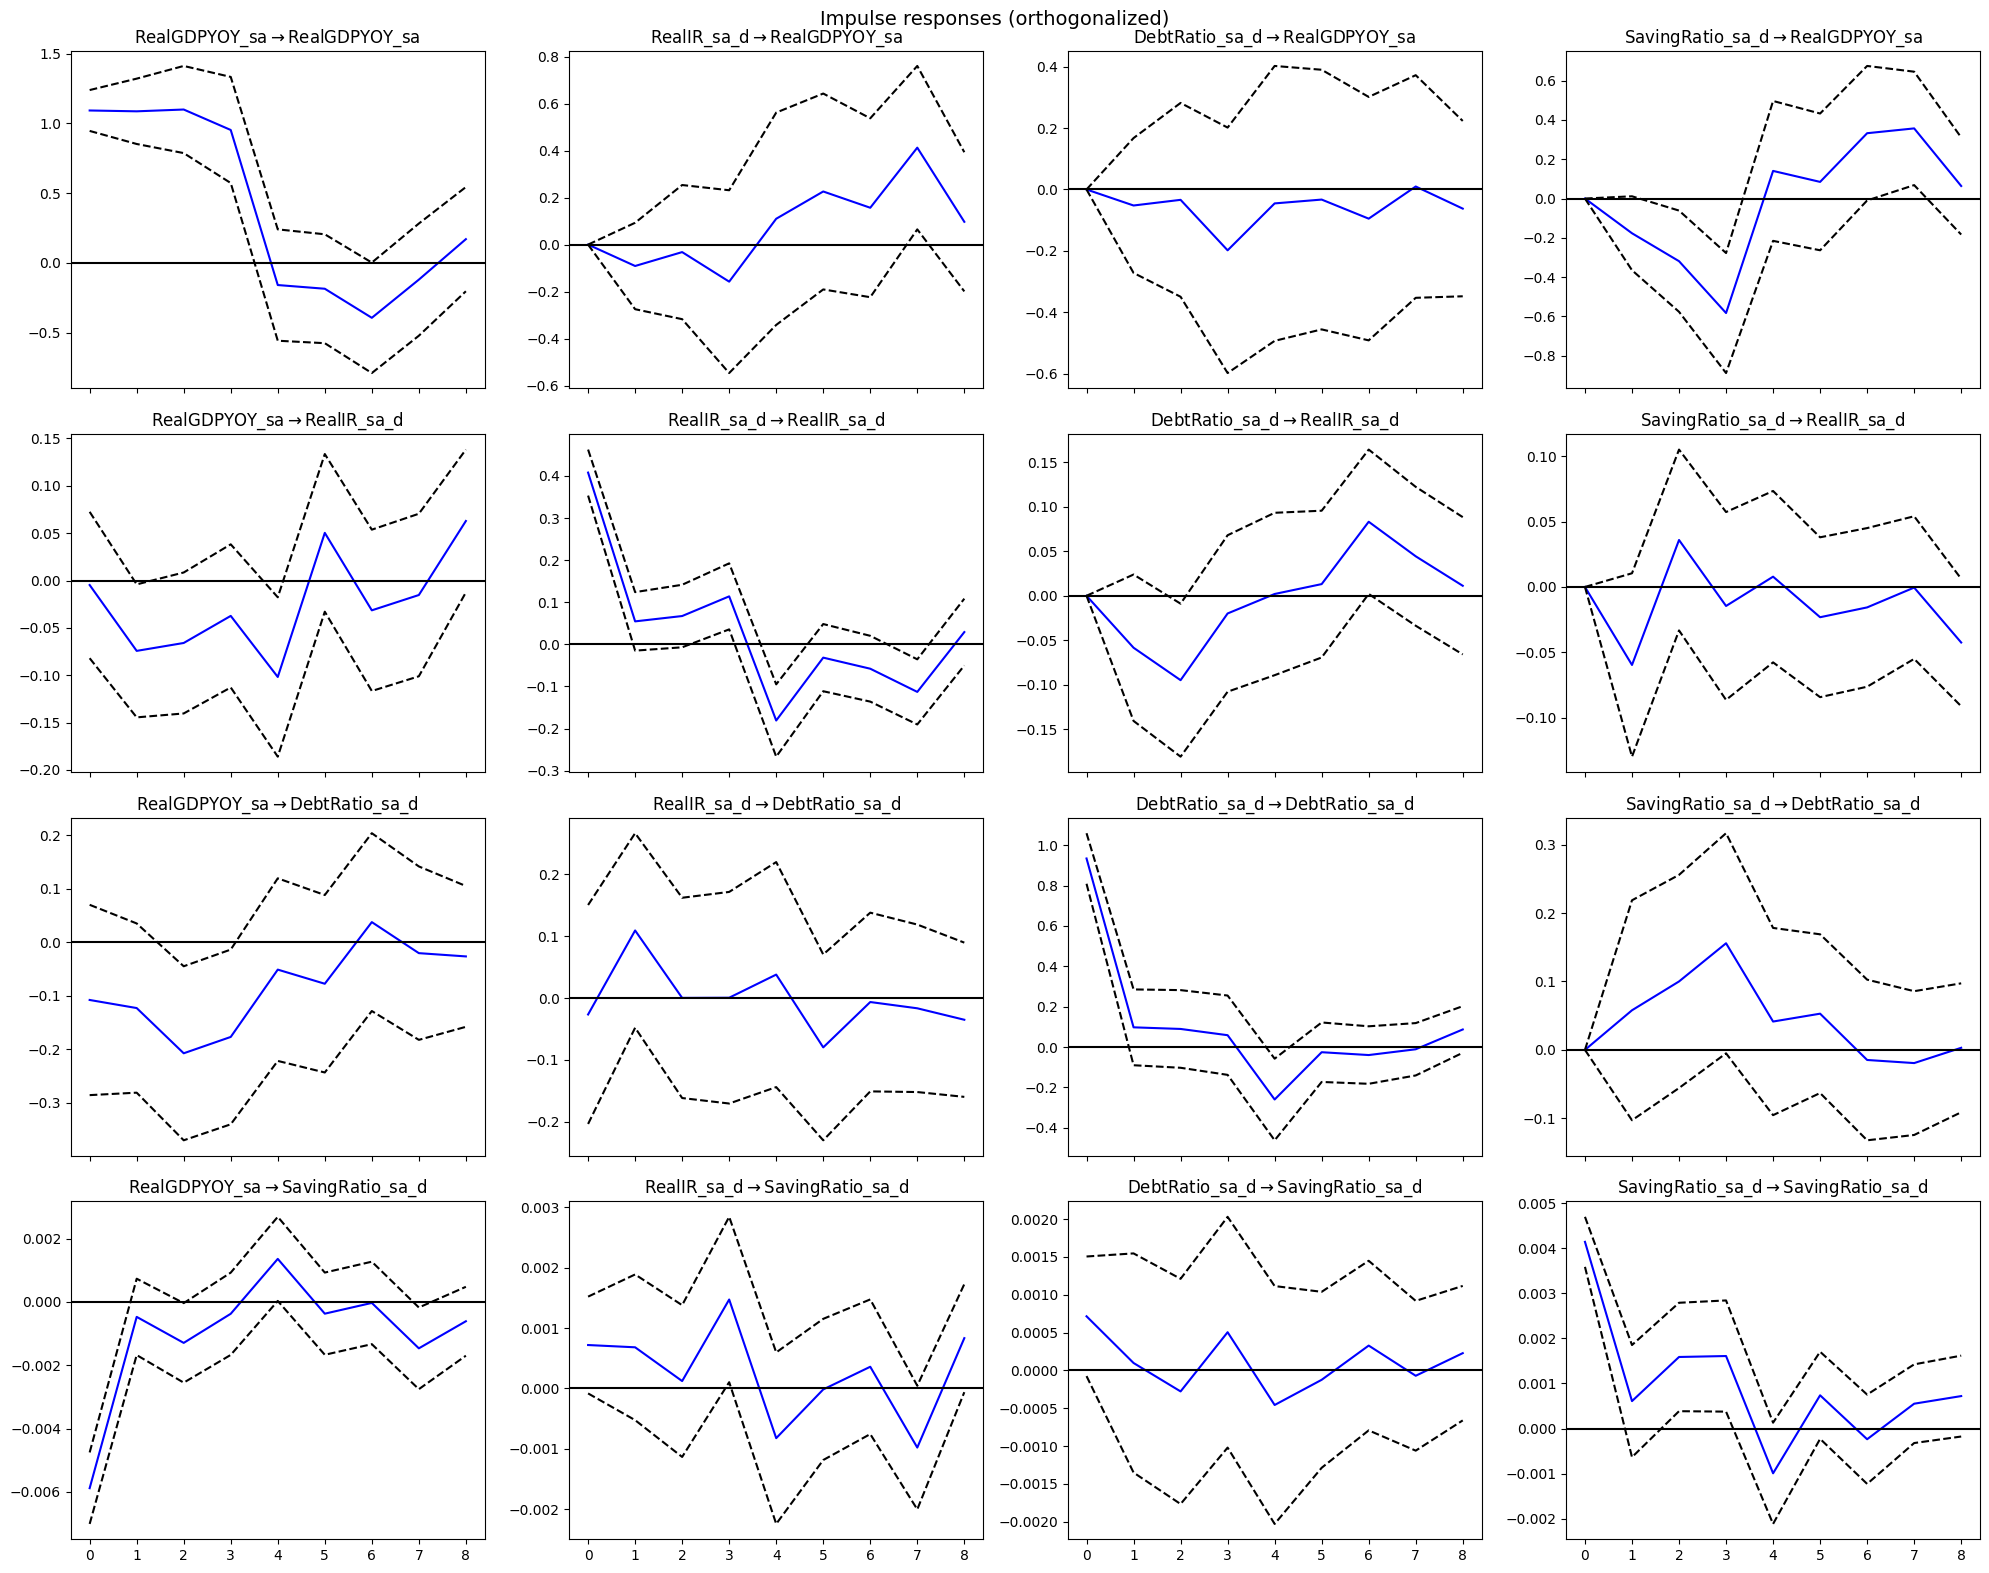

In [ ]:
# IRF of VAR(4) which Oil is exogenous
irf = results.irf(periods=8)

# Plot ทุก impulse-response pairs
fig = irf.plot(orth=True, figsize=(20, 16))
plt.tight_layout()
plt.show()

## 4. Interpret (Key findings)
1. SavingRatio → RealGDPYOY (Granger p=0.0000)
    A positive shock to the saving ratio leads to a **negative** response in GDP growth during the first 1-3 quarters before gradually reverting to zero. This suggests that when households increase saving in the short run, consumption declines and GDP growth slows. This is consistent with the paradox of thrift, where higher aggregate saving can reduce aggregate demand in the short run. The finding aligns with Japan's experience during the Lost Decades, where persistently high household saving coincided with prolonged economic stagnation.

2. RealGDPYOY → RealIR (Granger p=0.0049)
    A positive shock to GDP growth produces a **slightly negative** response in the real interest rate during the first 1-2 quarters, followed by oscillation around zero. This implies that even when the economy improves, the Bank of Japan maintains its accommodative monetary stance rather than tightening. The muted response reflects the fact that Japan has operated near the zero lower bound for most of the sample period, leaving limited room for conventional interest rate adjustments in response to economic fluctuations.

3. RealGDPYOY → SavingRatio (Granger p=0.0405)
    A positive shock to GDP growth results in a **small negative** response in the saving ratio during the first 1-2 quarters, with a very small magnitude (0.001-0.002). This indicates that when economic conditions improve, households become more confident and increase consumption while reducing precautionary saving. This is consistent with the precautionary saving motive hypothesis, where reduced economic uncertainty lowers the incentive to save as a buffer against risk.

4. Debt Ratio shows no significant Granger causality with any variable in the short run, reflecting its slow-moving nature in the Japanese context.
5. All IRF responses are small and short-lived with confidence bands encompassing zero, indicating statistically insignificant responses at individual periods despite significant Granger causality.

Caveat: Although the confidence bands encompass zero in all three cases, indicating that the responses are not statistically significant at the 95% level at each individual period, the Granger causality tests confirm the existence of predictive relationships. The small and short-lived impacts reflect the structural characteristics of the Japanese economy, where these variables tend to move slowly under prolonged monetary easing and persistent deflationary pressures.

## 5. Consistency with Existing Literature

- The strong bidirectional causality between saving and GDP growth aligns with Horioka (2024), who identified domestic saving as a key structural feature of the Japanese economy and demonstrated that changes in the age structure of the population can largely explain trends in Japan's household saving rate (Horioka, C.Y., "Household Saving in Japan: The Past, Present, and Future," NBER Working Paper No. 33181, 2024).

- The weak real interest rate response to GDP growth reflects Japan's well-documented zero interest rate policy and unconventional monetary easing. Horioka, Nomoto, and Terada-Hagiwara (2014) noted that robust domestic saving combined with strong home bias enabled Japan to maintain low interest rates despite massive government debt (Horioka, C.Y., Nomoto, T., and Terada-Hagiwara, A., "Why Has Japan's Massive Government Debt Not Wreaked Havoc (Yet)?," NBER Working Paper No. 19596, 2014).

- The paradox of thrift interpretation of the negative saving-to-GDP impulse response is consistent with Horioka (2006), who found that the causes of Japan's Lost Decade included stagnation of household consumption driven by increased uncertainty and precautionary saving motives (Horioka, C.Y., "The Causes of Japan's 'Lost Decade'," NBER Working Paper No. 12142, 2006).

- The debt-to-GDP ratio, while remaining below the threshold — Lombardi et al. (2017, BIS Working Paper No. 607) found that household debt begins to recover as a percentage of GDP growth when the ratio exceeds 80% of GDP, but Japan has remained at 60-77% throughout the sample, which would negate that threshold.

- Debt in Japan is a slow-moving variable — Ogawa and Wan (2007) found that household debt to consumption in Japan operates through balance sheet channels and its long-term, heavy impact on wealth is the short-term dynamic that VAR captures.

- Corporate debt is just household debt — Koo (2008, "The Holy Grail of Macroeconomics: Lessons from Japan's Great Recession") argues that the balance sheet is the revolutionary recession driven by corporate sector deleveraging, essentially household debt.

## 6. Conclusion
1. Quarterly data from 1997Q4 to 2025Q3, seasonal adjustment was applied to CPI, Debt Ratio, and Saving Ratio using STL decomposition before estimation, ADF tests confirmed all variables are I(1) to be stationary.
2. VAR(4) was selected based on BIC, FPE, and HQIC criteria unanimously choosing lag 4, Engle-Granger two-step shows there no cointegration.
3. Stability condition was satisfied with all eigenvalues inside the unit circle, portmanteau test shows no serial correlation.
4. SavingRatio strongly Granger-causes RealGDPYOY (p=0.0000): a positive saving shock leads to a negative GDP growth response in the first 1-3 quarters, consistent with the paradox of thrift observed during Japan's Lost Decades
5. Debt Ratio shows no significant Granger causality with any variable in the short run, reflecting its slow-moving nature in the Japanese context
6. All IRF responses are small and short-lived with confidence bands encompassing zero, indicating statistically insignificant responses at individual periods despite significant Granger causality
7. Our finding are consistency with existing literature.